In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
# !pip install -e SPICE

In [3]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from spice import SpiceEstimator, SpiceConfig, csv_to_dataset, BaseModel, plot_session, split_data_along_blockdim

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from benchmarking_braun2018 import ExpectedValueControl, get_dataset, generate_behavior
from spice_braun2018 import SpiceModel, CONFIG

# For custom RNN
import torch
import torch.nn as nn

# NOTEBOOK CONFIG

In [4]:
train_spice = False
train_evc = False
train_gru = False

# DATASET

## Load dataset

In [5]:
dataset_train, dataset_test, _ = get_dataset(verbose=True)

Shape of dataset: torch.Size([756, 274, 1, 10])
Number of participants: 63
Number of actions in dataset: 2


## Dataset processing

In [6]:
# seems like there are a few blocks that are way longer than the average block
# maybe limiting the block length to a given size would help
n_trials_per_block = np.zeros(dataset_train.xs.shape[0])
for index, block in enumerate(dataset_train.xs[:, :, 0, 0]):
    n_trials_per_block[index] = block.shape[0]-block.isnan().sum()

mean, std = n_trials_per_block.mean(), n_trials_per_block.std()

print(f"Average sequence length: {int(mean)}+-{int(std)}")
print(f"Old max sequence length is {dataset_train.xs.shape[1]}")

# it would be okay to limit until ca mean+2*std trials per  (~200 trials)
dataset_train.xs = dataset_train.xs[:, :int(mean+2*std)]
dataset_train.ys = dataset_train.ys[:, :int(mean+2*std)]

print(f"New max sequence length is {dataset_train.xs.shape[1]}")

Average sequence length: 66+-39
Old max sequence length is 274
New max sequence length is 145


In [7]:
# seems like there are a few blocks that are way longer than the average block
# maybe limiting the block length to a given size would help
n_trials_per_block = np.zeros(dataset_test.xs.shape[0])
for index, block in enumerate(dataset_test.xs[:, :, 0, 0]):
    n_trials_per_block[index] = block.shape[0]-block.isnan().sum()

mean, std = n_trials_per_block.mean(), n_trials_per_block.std()

print(f"Average sequence length: {int(mean)}+-{int(std)}")
print(f"Old max sequence length is {dataset_test.xs.shape[1]}")

# it would be okay to limit until ca mean+2*std trials per  (~200 trials)
dataset_test.xs = dataset_test.xs[:, :int(mean+2*std)]
dataset_test.ys = dataset_test.ys[:, :int(mean+2*std)]

print(f"New max sequence length is {dataset_test.xs.shape[1]}")

Average sequence length: 67+-34
Old max sequence length is 274
New max sequence length is 136


# SPICE

## SPICE Setup

Let's setup now the `SpiceEstimator` object and fit it to the data!

In [8]:
path_spice = 'params/spice_braun2018.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=SpiceModel,
        spice_config=CONFIG,
        n_actions=2,
        n_participants=dataset_train.n_participants,
        n_experiments=1,
        n_reward_features=0,
        
        epochs=1000,
        warmup_steps=500,

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        verbose=True,
        save_path_spice=path_spice,
    )

In [9]:
if train_spice:
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [10]:
estimator.load_spice(path_spice)

# BENCHMARKING

### Expected Value of Control Model (Shenhav et al., 2013)

In [11]:
path_spice = 'params/spice_braun2018.pkl'

evc = ExpectedValueControl(n_participants=dataset_train.n_participants)
path_evc = path_spice.replace('spice_', 'evc_')

In [12]:
if train_evc:
    optimizer_evc = torch.optim.Adam(evc.parameters(), lr=0.01)
    epochs = 1000

    evc = training(
        model=evc,
        optimizer=optimizer_evc,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        device=torch.device('cpu'),
    )

    torch.save(evc.state_dict(), path_evc)

In [13]:
evc.load_state_dict(torch.load(path_evc, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [14]:
gru = GRUModel(dataset_train.n_actions, additional_inputs=4, n_reward_features=0)
path_gru = path_spice.replace('spice_', 'gru_')

In [15]:
if train_gru:
    epochs = 1000
    optimizer_gru = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu')),
        optimizer=optimizer_gru,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        ).to(torch.device('cpu'))

    torch.save(gru.state_dict(), path_gru)

In [16]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))
# gru.to(torch.device('cpu')).eval()

<All keys matched successfully>

# ANALYSIS

In [17]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals

In [18]:
estimator.eval()
evc.eval()
gru.eval()

GRUModel(
  (participant_embedding): Embedding(1, 16)
  (experiment_embedding): Embedding(1, 16)
  (linear_in): Linear(in_features=6, out_features=16, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (gru): GRU(16, 16, batch_first=True)
  (linear_out): Linear(in_features=16, out_features=2, bias=True)
)

## Analysis model evaluation

In [19]:
print("Model evaluation on training data (for AIC and BIC): ")
analysis_model_evaluation(
    dataset=dataset_train,
    spice_model=estimator,
    benchmark_model=evc,
    gru_model=gru,
)

Model evaluation on training data (for AIC and BIC): 
Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC,ΔBIC/trial
Benchmark,0.570419,0.155806,5.000000,0.000000,20643.751953,41297.503906,41340.066406,0.262098
GRU,0.696628,0.152761,1810.000000,0.000000,13293.589844,30207.179688,45614.835938,0.145851
SPICE-RNN,0.667695,0.149850,12368.000000,0.000000,14853.480469,54442.960938,159725.796875,-2.957267
SPICE-EQ,0.554218,0.133504,11.095239,0.797461,21703.312500,43428.816406,43523.265625,0.202729


In [20]:
print("Model evaluation on held-out data (for average trial likelihood and NLL): ")
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    benchmark_model=evc,
    gru_model=gru,
    output_dir='results',
)

Model evaluation on held-out data (for average trial likelihood and NLL): 
Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC,ΔBIC/trial
Benchmark,0.546326,0.159768,5.000000,0.000000,7515.628906,15041.257812,15078.398438,0.173424
GRU,0.662498,0.155989,1810.000000,0.000000,5118.724609,13857.449219,27302.181641,-0.809827
SPICE-RNN,0.653976,0.147707,12368.000000,0.000000,5279.683594,35295.367188,127165.234375,-8.842569
SPICE-EQ,0.546696,0.131188,11.095239,0.797461,7507.224609,15036.639648,15119.055664,0.170154


## Analysis generative behavior

In [21]:
generated_dataset_spice = generate_behavior(
    dataset=dataset_train,
    model=estimator,
    save_dataset='data/braun2018_spice.csv'
)

generated_dataset_benchmark = generate_behavior(
    dataset=dataset_train,
    model=evc,
    save_dataset='data/braun2018_benchmark.csv'
)

generated_dataset_gru = generate_behavior(
    dataset=dataset_train,
    model=gru,
    save_dataset='data/braun2018_gru.csv'
)

Generating behavior...


100%|██████████| 145/145 [00:00<00:00, 295.22it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 145/145 [00:00<00:00, 977.70it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 145/145 [00:00<00:00, 1804.34it/s]


Done generating behavior.


In [22]:
from analysis_generative import analysis_generative_behavior

Loading real from data/braun2018.csv...
Loading benchmark from data/braun2018_benchmark.csv...
Loading gru from data/braun2018_gru.csv...
Loading spice_rnn from data/braun2018_spice.csv...
Loading spice from data/braun2018_spice.csv...
                 P(Switch) P(Switch | Both Change) P(Switch | Neither Change)  \
Model                                                                           
real       0.368 +/- 0.273         0.299 +/- 0.266            0.412 +/- 0.321   
benchmark  0.368 +/- 0.239         0.375 +/- 0.257            0.353 +/- 0.272   
gru        0.452 +/- 0.191         0.453 +/- 0.240            0.448 +/- 0.227   
spice_rnn  0.642 +/- 0.227         0.651 +/- 0.239            0.640 +/- 0.264   
spice      0.642 +/- 0.227         0.651 +/- 0.239            0.640 +/- 0.264   

          P(Switch | Current Decrease) P(Switch | Other Increase)  \
Model                                                               
real                   0.337 +/- 0.266            0.339 +/

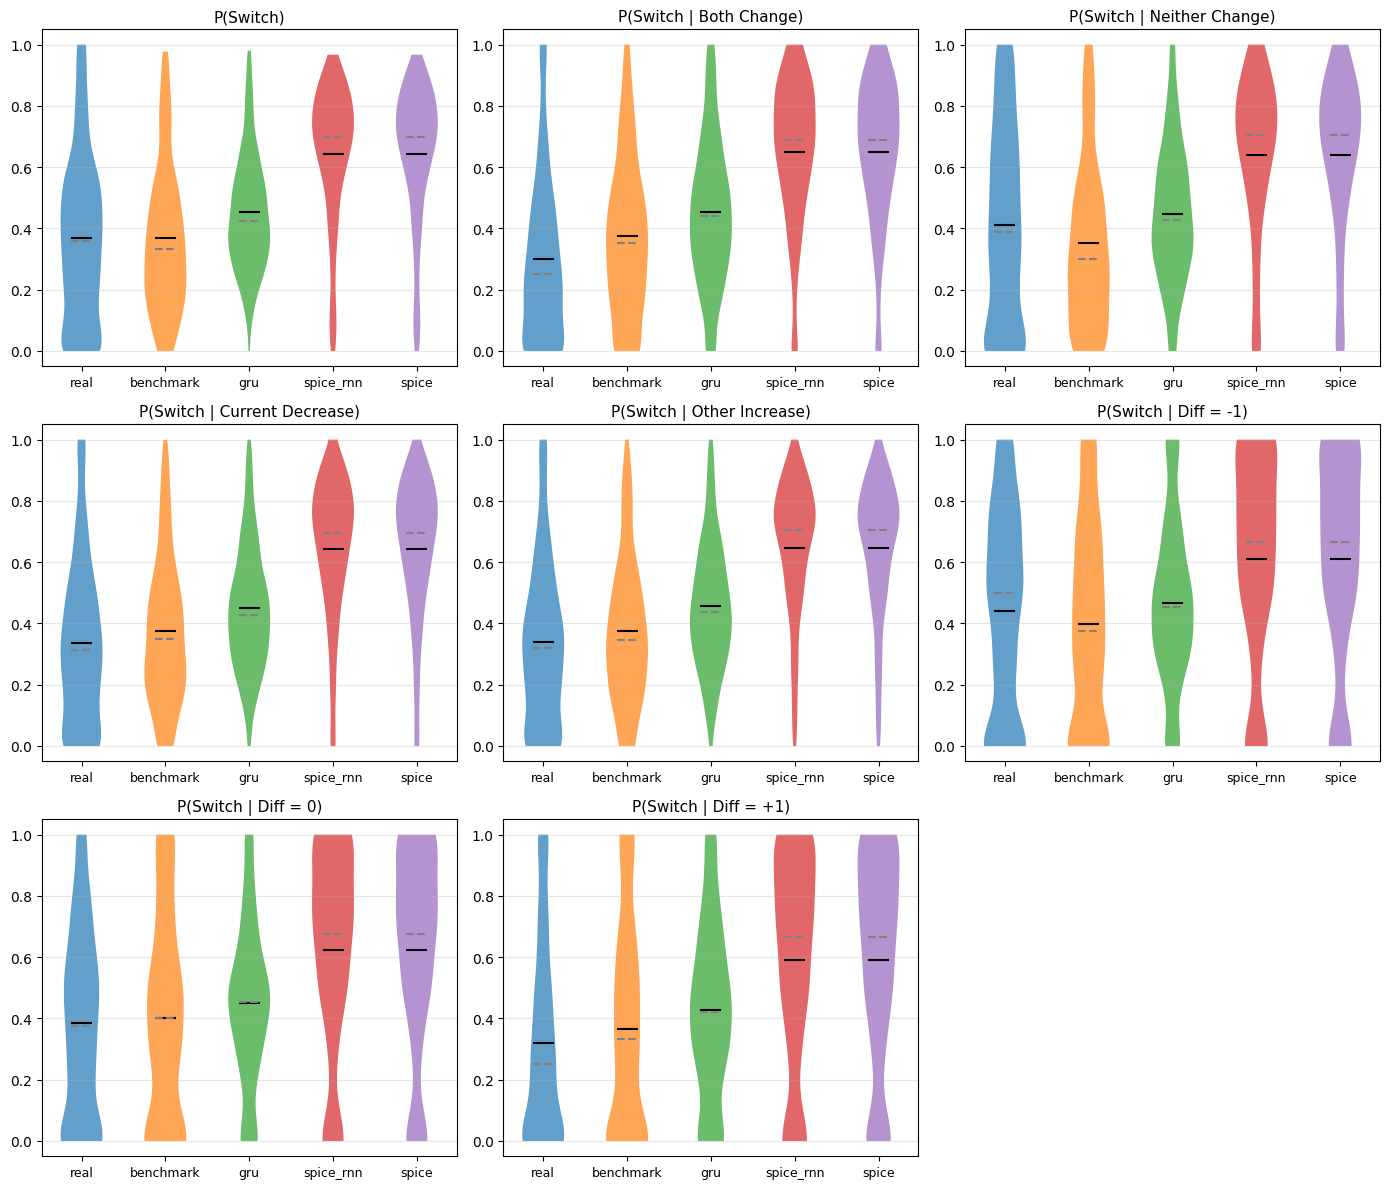


Normalized MAE (|model_mean - real_mean| / real_std):
          P(Switch) P(Switch | Both Change) P(Switch | Neither Change)  \
Model                                                                    
benchmark    0.0007                  0.2882                     0.1850   
gru          0.3088                  0.5787                     0.1135   
spice_rnn    1.0030                  1.3247                     0.7109   
spice        1.0030                  1.3247                     0.7109   

          P(Switch | Current Decrease) P(Switch | Other Increase)  \
Model                                                               
benchmark                       0.1388                     0.1377   
gru                             0.4245                     0.4455   
spice_rnn                       1.1536                     1.1612   
spice                           1.1536                     1.1612   

          P(Switch | Diff = -1) P(Switch | Diff = 0) P(Switch | Diff = +1)  \
Model  

(                 P(Switch) P(Switch | Both Change) P(Switch | Neither Change)  \
 Model                                                                           
 real       0.368 +/- 0.273         0.299 +/- 0.266            0.412 +/- 0.321   
 benchmark  0.368 +/- 0.239         0.375 +/- 0.257            0.353 +/- 0.272   
 gru        0.452 +/- 0.191         0.453 +/- 0.240            0.448 +/- 0.227   
 spice_rnn  0.642 +/- 0.227         0.651 +/- 0.239            0.640 +/- 0.264   
 spice      0.642 +/- 0.227         0.651 +/- 0.239            0.640 +/- 0.264   
 
           P(Switch | Current Decrease) P(Switch | Other Increase)  \
 Model                                                               
 real                   0.337 +/- 0.266            0.339 +/- 0.264   
 benchmark              0.374 +/- 0.240            0.376 +/- 0.238   
 gru                    0.450 +/- 0.205            0.457 +/- 0.208   
 spice_rnn              0.644 +/- 0.230            0.646 +/- 0.223   
 spi

In [23]:
analysis_generative_behavior(
    path_data_real='data/braun2018.csv',
    path_data_benchmark='data/braun2018_benchmark.csv',
    path_data_gru='data/braun2018_gru.csv',
    path_data_spice_rnn='data/braun2018_spice.csv',
    path_data_spice='data/braun2018_spice.csv',
    output_dir='results',
)

## Analysis coefficient distribution

In [24]:
analysis_coefficients_distributions(
    spice_model=estimator,
    output_dir='results',
)

Extracting coefficient data...
  Ensemble=10, Participants=63, Experiments=1, Modules=6, Total terms=24

ANALYSIS 1: Ensemble Consistency
  Mean presence agreement: 1.000
  Mean presence rate:      0.462
  Mean CV:                 3.050
  Ensemble spread plots saved.
  Ensemble CV heatmaps saved.

ANALYSIS 2: Coefficient Distributions
  Terms with >50% presence: 11 / 24
  Terms with 0% presence:   12 / 24
  Violin plots saved.
  Presence rate bar chart saved.
  Experiment comparison skipped (X=1).
  Sparsity heatmaps saved.

All results saved to: results


(            module                term  term_index  presence_agreement_mean  \
 0    reward_repeat                   1           0                      1.0   
 1    reward_repeat       dreward_tasks           1                      1.0   
 2    reward_repeat     dreward_tasks^2           2                      1.0   
 3    reward_switch                   1           0                      1.0   
 4    reward_switch       dreward_tasks           1                      1.0   
 5    reward_switch     dreward_tasks^2           2                      1.0   
 6      task_repeat                   1           0                      1.0   
 7      task_repeat         task_repeat           1                      1.0   
 8      task_repeat              repeat           2                      1.0   
 9      task_repeat       task_repeat^2           3                      1.0   
 10     task_repeat  task_repeat*repeat           4                      1.0   
 11     task_repeat            repeat^2 

## Analysis coefficients individuals